<a href="https://colab.research.google.com/github/jm651120/UK-Housing-Green-Premium/blob/main/notebooks/02_EDA_and_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2: Exploratory Data Analysis & Machine Learning Modelling
**Project:** Impact of Energy Efficiency on UK House Prices (2021-2025)  
**Description:** This notebook performs EDA on the cleaned dataset and executes the modelling strategy (OLS Baseline vs. Advanced ML Models).

In [ ]:
!pip install contextily pyproj --quiet

In [ ]:
# Global Setup
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, LogNorm, ListedColormap
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import contextily as ctx
from pyproj import Transformer
import re
from sklearn.model_selection import train_test_split
from scipy.stats import gaussian_kde


# Mount Drive and load data
drive.mount('/content/drive')
caminho_csv = '/content/drive/MyDrive/Tese/UK DataSets/Dataset_Final_Tese.csv'
df = pd.read_csv(caminho_csv)
print(f"✅ Dataset loaded successfully: {len(df):,} rows.")

# ─── UNIFIED AESTHETIC STANDARD ──────────────────────────────────────────────
sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.figsize':       (12, 6),
    'axes.titlesize':       14,
    'axes.titlepad':        16,
    'axes.labelsize':       12,
    'xtick.labelsize':      10,
    'ytick.labelsize':      10,
    'legend.fontsize':      9,
    'legend.title_fontsize': 11,
})

# Palette constants — reference these in every plot cell
ACCENT = 'steelblue'
PAL_EPC = sns.color_palette("RdYlGn_r", 7) # semantic: green = A (efficient), red = G (inefficient)
PAL_CAT = 'mako'                            # non-semantic categorical / heatmap
PAL_CONT = 'viridis'                        # continuous / spatial / ordinal-time scale
# ─────────────────────────────────────────────────────────────────────────────

Mounted at /content/drive
✅ Dataset loaded successfully: 547,948 rows.


## Step 2: Correlation Analysis
In this phase, the Pearson correlation matrix is calculated for the continuous variables. The objective is to quantify the strength of the linear relationship between property price and its physical and spatial attributes, thereby identifying the most significant predictors for the regression models.

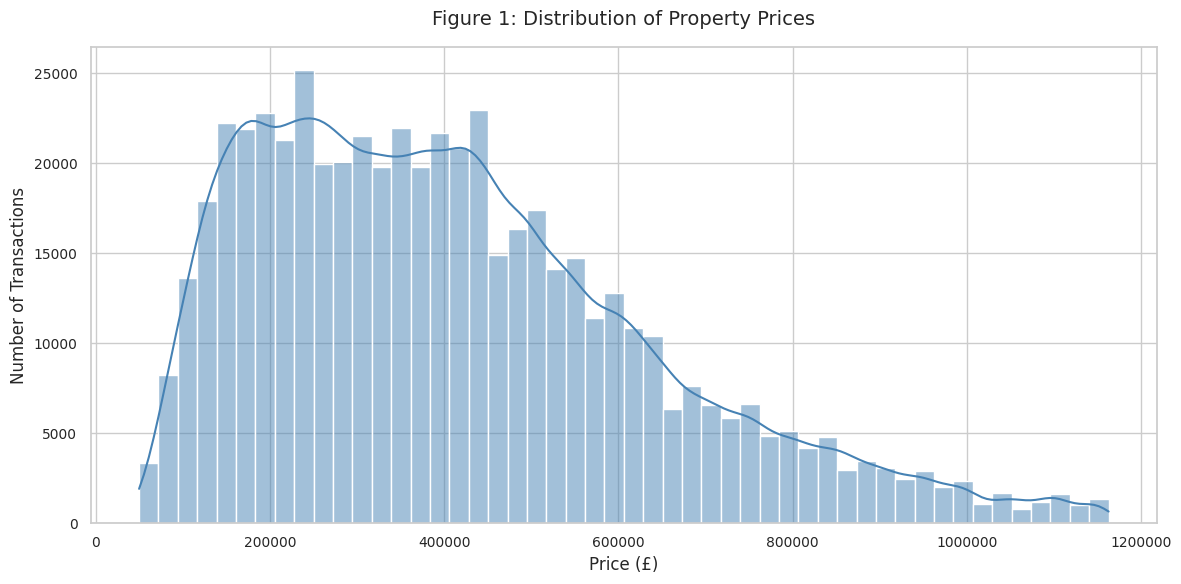

In [ ]:
# Figure 1 B — Distribution of Property Prices

plt.figure(figsize=(12, 6))
sns.histplot(df['Price'], bins=50, kde=True, color=ACCENT)

plt.title('Figure 1: Distribution of Property Prices', fontsize=14, pad=16)
plt.xlabel('Price (£)', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

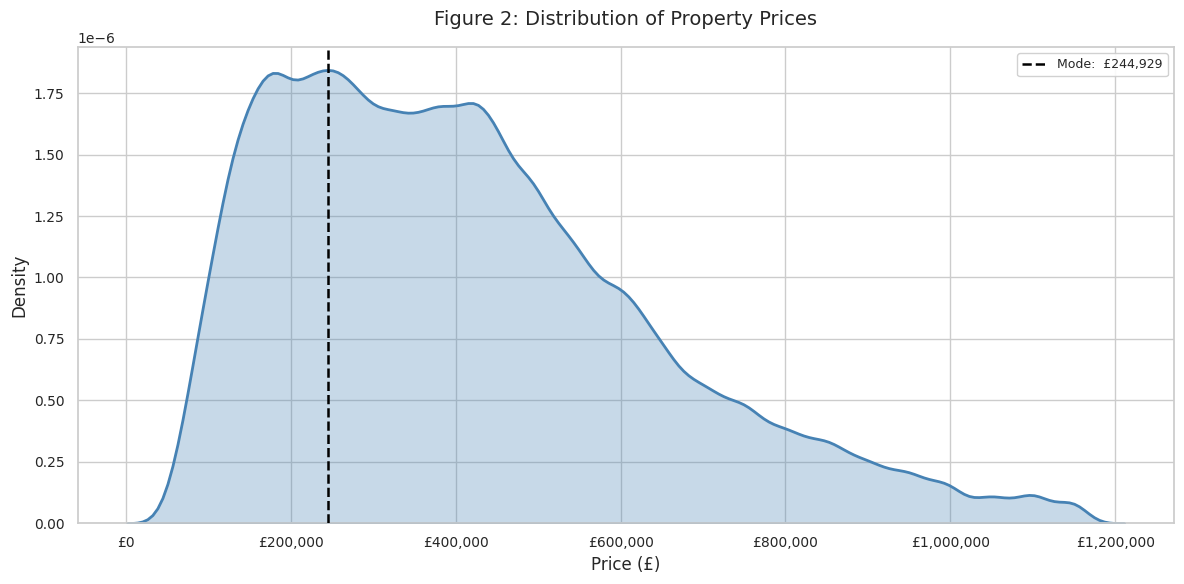


KDE Mode of property price distribution: £244,929


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Figure 1 B — Distribution of Property Prices (KDE line chart + Mode)
# ══════════════════════════════════════════════════════════════════════════════

prices = df['Price'].dropna().values

# ── Programmatically locate the mode as the peak of the KDE curve ─────────────
# Using scipy gaussian_kde so the mode matches exactly where the plotted
# curve peaks — more meaningful than df['Price'].mode() on continuous data.
kde_estimator = gaussian_kde(prices, bw_method='scott')
x_grid        = np.linspace(prices.min(), prices.max(), 10_000)
kde_values    = kde_estimator(x_grid)
mode_price    = x_grid[np.argmax(kde_values)]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

sns.kdeplot(
    data    = prices,
    ax      = ax,
    color   = ACCENT,
    fill    = True,
    alpha   = 0.30,
    linewidth = 2.0,
    bw_method = 'scott',
)

# Mode vertical line
ax.axvline(
    x         = mode_price,
    color     = 'black',
    linewidth = 1.8,
    linestyle = '--',
    label     = f'Mode:  £{mode_price:,.0f}',
    zorder    = 5,
)

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_title('Figure 2: Distribution of Property Prices', pad=16)
ax.set_xlabel('Price (£)')
ax.set_ylabel('Density')

# Format x-axis ticks as £ currency without scientific notation
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f'£{val:,.0f}')
)

ax.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Tese/figure_3_2_price_distribution.png',
    dpi=300, bbox_inches='tight'
)
plt.show()

print(f"\nKDE Mode of property price distribution: £{mode_price:,.0f}")

/tmp/ipykernel_12564/3324252067.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


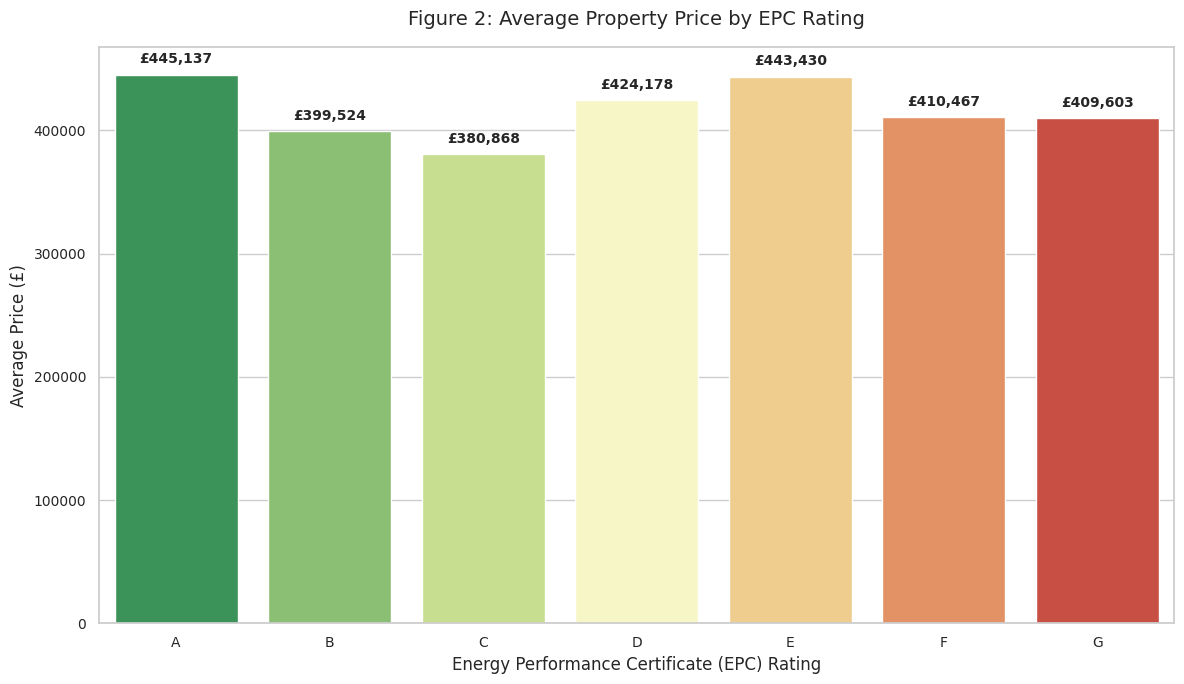

In [ ]:
# Figure 2 — Average Property Price by EPC Rating
# argument: green = energy-efficient = higher price; red = inefficient = lower price.
# Replacing it with a neutral palette would destroy the communicative intent of
# the "Green Premium / Brown Discount" narrative.

epc_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

df_epc_price = (
    df.groupby('CURRENT_ENERGY_RATING')['Price']
    .mean()
    .reindex(epc_order)
    .reset_index()
)

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x='CURRENT_ENERGY_RATING',
    y='Price',
    data=df_epc_price,
    palette=PAL_EPC,
    order=epc_order
)

plt.title('Figure 2: Average Property Price by EPC Rating', fontsize=14, pad=16)
plt.xlabel('Energy Performance Certificate (EPC) Rating', fontsize=12)
plt.ylabel('Average Price (£)', fontsize=12)

# Value annotations above each bar
for p in ax.patches:
    ax.annotate(
        f"£{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom',
        xytext=(0, 6),
        textcoords='offset points',
        fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()


## Step 3: Correlation Analysis
Nesta fase, calculamos a matriz de correlação de Pearson para as variáveis contínuas. O objetivo é quantificar a força da relação linear entre o preço e os atributos físicos e espaciais do imóvel, identificando os preditores mais significativos para os modelos de regressão.


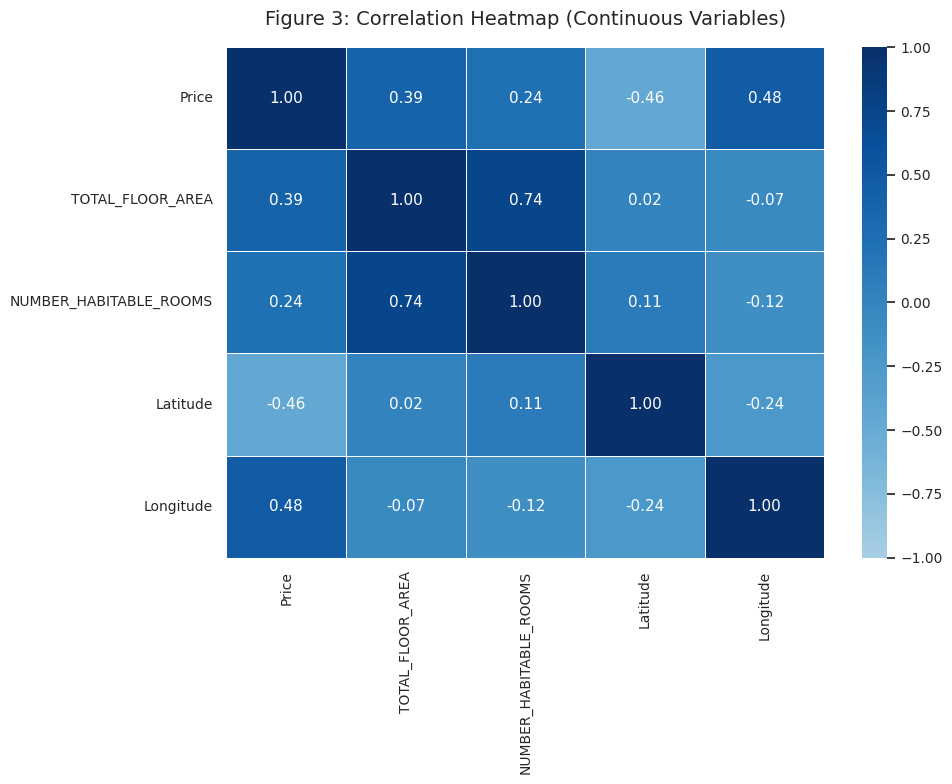

In [ ]:
# Figure 3 — Correlation Heatmap (Continuous Variables)

blues_d = LinearSegmentedColormap.from_list(
    'blues_d', plt.cm.Blues(np.linspace(0.35, 1.0, 256))
)

cols_num    = ['Price', 'TOTAL_FLOOR_AREA', 'NUMBER_HABITABLE_ROOMS', 'Latitude', 'Longitude']
corr_matrix = df[cols_num].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot      = True,
    cmap       = blues_d,
    vmin       = -1,
    vmax       =  1,
    center     =  0,
    fmt        = '.2f',
    linewidths = 0.5,
    annot_kws  = {'size': 11},
)

plt.title('Figure 3: Correlation Heatmap (Continuous Variables)', fontsize=14, pad=16)
plt.tight_layout()
plt.show()

### Step 3.1: Temporal and Spatial Analysis (Market Dynamics)

Beyond the intrinsic characteristics of the properties, the 'Green Premium' and house prices are heavily influenced by macroeconomic factors over time and geographic location.

1. **Temporal Evolution (2021-2025):** The average price fluctuation across months is evaluated to justify the inclusion of `Year_of_Transfer` and `Month_of_Transfer` in the model, capturing inflation effects and post-COVID market shocks.
2. **Spatial Distribution:** Transactions are mapped based on `Latitude` and `Longitude`. This visualisation demonstrates the spatial heterogeneity of the market across the three studied regions (Greater London, Greater Manchester, and Cornwall), justifying the use of spatial fixed effects (*Outcodes*) in the OLS model and raw coordinates in the Machine Learning models.

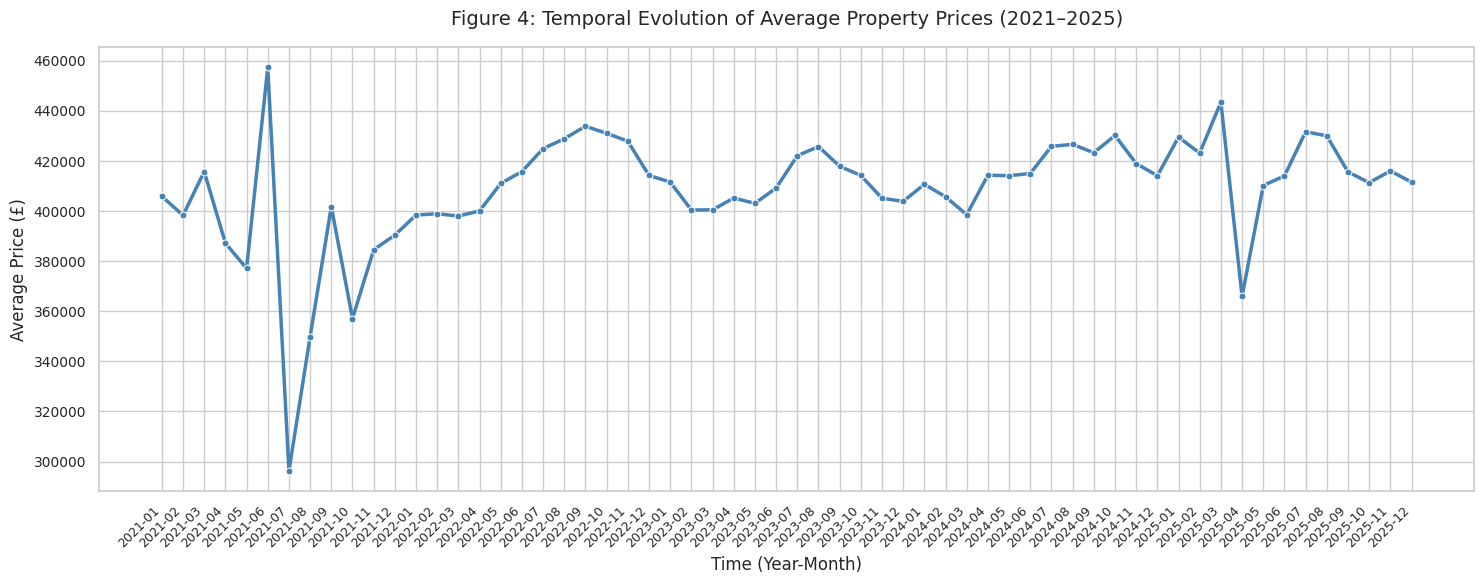

In [ ]:
# Figure 4 — Temporal Evolution of Average Property Prices

df['YearMonth'] = (
    df['Year_of_Transfer'].astype(str) + '-' +
    df['Month_of_Transfer'].astype(str).str.zfill(2)
)
df_temporal = (
    df.groupby('YearMonth')['Price']
    .mean()
    .reset_index()
    .sort_values('YearMonth')
)

plt.figure(figsize=(15, 6))
sns.lineplot(
    x='YearMonth',
    y='Price',
    data=df_temporal,
    color=ACCENT,
    linewidth=2.5,
    marker='o',
    markersize=5
)

plt.title('Figure 4: Temporal Evolution of Average Property Prices (2021–2025)', fontsize=14, pad=16)
plt.xlabel('Time (Year-Month)', fontsize=12)
plt.ylabel('Average Price (£)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)

plt.tight_layout()
plt.show()

df.drop(columns=['YearMonth'], inplace=True)

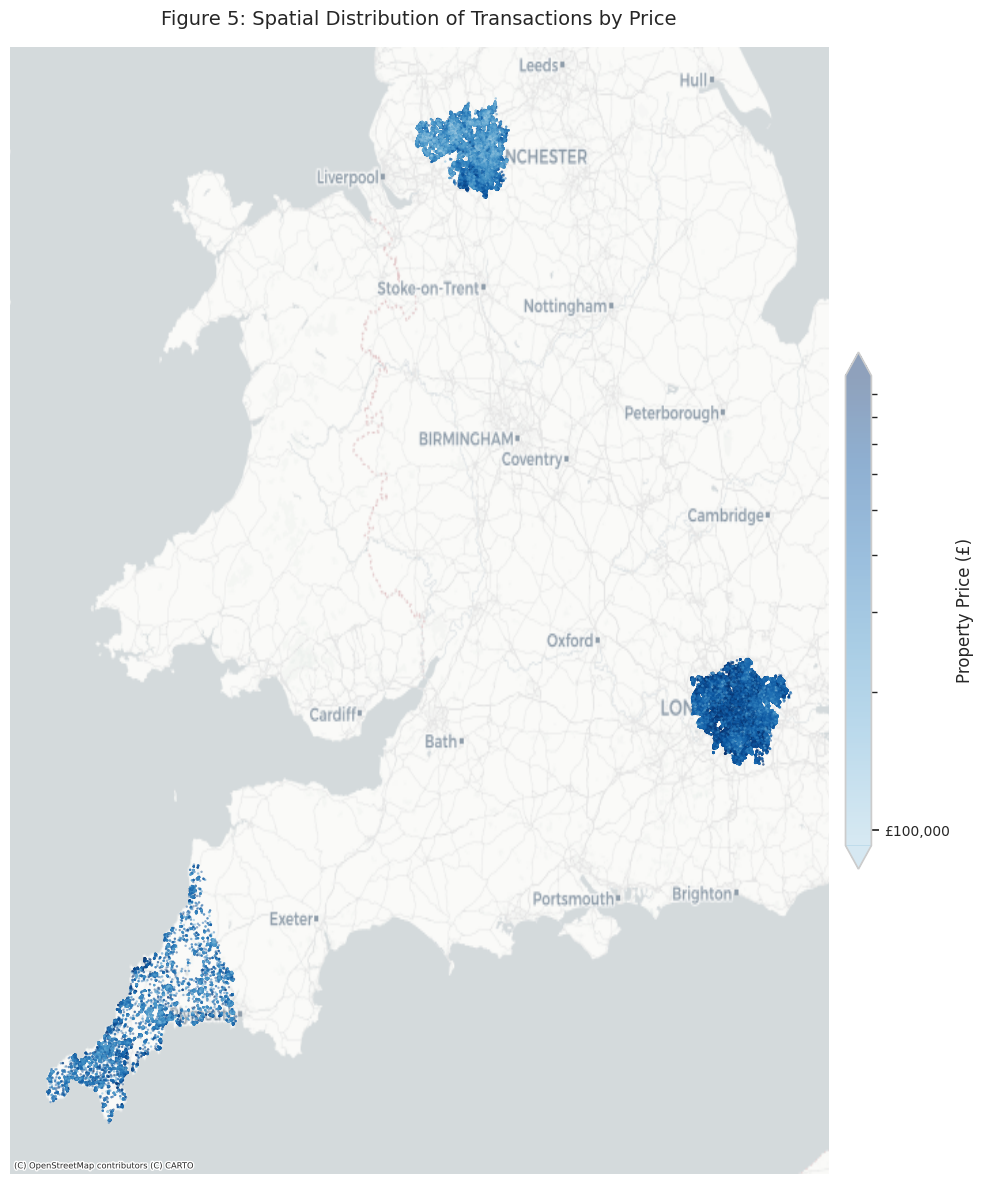

Colour scale: £92,500 (2nd pct) → £985,000 (98th pct) — log normalised


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Figure 5 — Spatial Distribution of Transactions by Price
# ══════════════════════════════════════════════════════════════════════════════

# ── 1. Blues_d equivalent ─────────────────────────────────────────────────────
# Seaborn's Blues_d skips the very light end of the Blues ramp to keep all
# colours readable against a light basemap. We replicate that here by slicing
# matplotlib's Blues cmap from 35 % onwards.
blues_d = LinearSegmentedColormap.from_list(
    'blues_d', plt.cm.Blues(np.linspace(0.35, 1.0, 256))
)

# ── 2. Reproject WGS-84 → Web Mercator (required by contextily) ──────────────
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
x_merc, y_merc = transformer.transform(
    df['Longitude'].values,
    df['Latitude'].values
)

# ── 3. Colour normalisation ───────────────────────────────────────────────────
# House prices are log-normally distributed; a log norm prevents the handful
# of high-value outliers from washing out all colour variation in the bulk.
# Clip to 2nd–98th percentile so extreme values do not dominate the scale.
p_low  = df['Price'].quantile(0.02)
p_high = df['Price'].quantile(0.98)
norm   = LogNorm(vmin=p_low, vmax=p_high)

# ── 4. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 12))

sc = ax.scatter(
    x_merc, y_merc,
    c          = df['Price'].values,
    cmap       = blues_d,
    norm       = norm,
    s          = 3,
    alpha      = 0.45,
    linewidths = 0,          # no marker border — cleaner at this density
    rasterized = True,       # critical: rasterise the point cloud so the
)                            # saved PNG/PDF does not embed 514 K vector paths

# ── 5. Basemap ────────────────────────────────────────────────────────────────
# CartoDB Positron: clean light grey tiles, no API token required,
# road labels minimal — ideal backing for a dense point overlay.
ctx.add_basemap(
    ax,
    source = ctx.providers.CartoDB.Positron,
    zoom   = 'auto',
    attribution_size = 6,    # small attribution text — required by tile licence
)

# ── 6. Colorbar ───────────────────────────────────────────────────────────────
cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02, extend='both')
cbar.set_label('Property Price (£)', fontsize=12)
cbar.ax.yaxis.set_major_formatter(
    FuncFormatter(lambda val, _: f'£{val:,.0f}')
)

# ── 7. Title and axes ─────────────────────────────────────────────────────────
ax.set_title(
    'Figure 5: Spatial Distribution of Transactions by Price',
    fontsize=14, pad=16
)
# Lat/Lon axis labels are meaningless in Web Mercator metre coordinates;
# the basemap provides all necessary geographic context.
ax.set_axis_off()

plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Tese/figure_3_5_spatial_distribution.png',
    dpi=300, bbox_inches='tight'
)
plt.show()
print(f"Colour scale: £{p_low:,.0f} (2nd pct) → £{p_high:,.0f} (98th pct) — log normalised")

### Step 3.2: Energy Efficiency Profiling (Regional and Structural)

To truly understand the 'Green Premium', it is imperative to analyse how Energy Performance Certificates (EPC) are distributed across the housing stock.

1. **Regional Energy Profile:** The proportion of each EPC rating is compared across Greater London, Greater Manchester, and Cornwall. This analysis reveals asymmetries in the housing stock (e.g., more rural areas or those with fewer newly constructed properties tend to have a higher prevalence of lower ratings), justifying the need to control for spatial effects in the modelling.
2. **Impact of Construction Age on EPC:** The relationship between `CONSTRUCTION_AGE_BAND` and `CURRENT_ENERGY_RATING` is evaluated. Since the UK possesses a vast number of unretrofitted historical properties, a strong correlation is expected between older houses and poorer energy ratings, confirming age as a critical control variable.

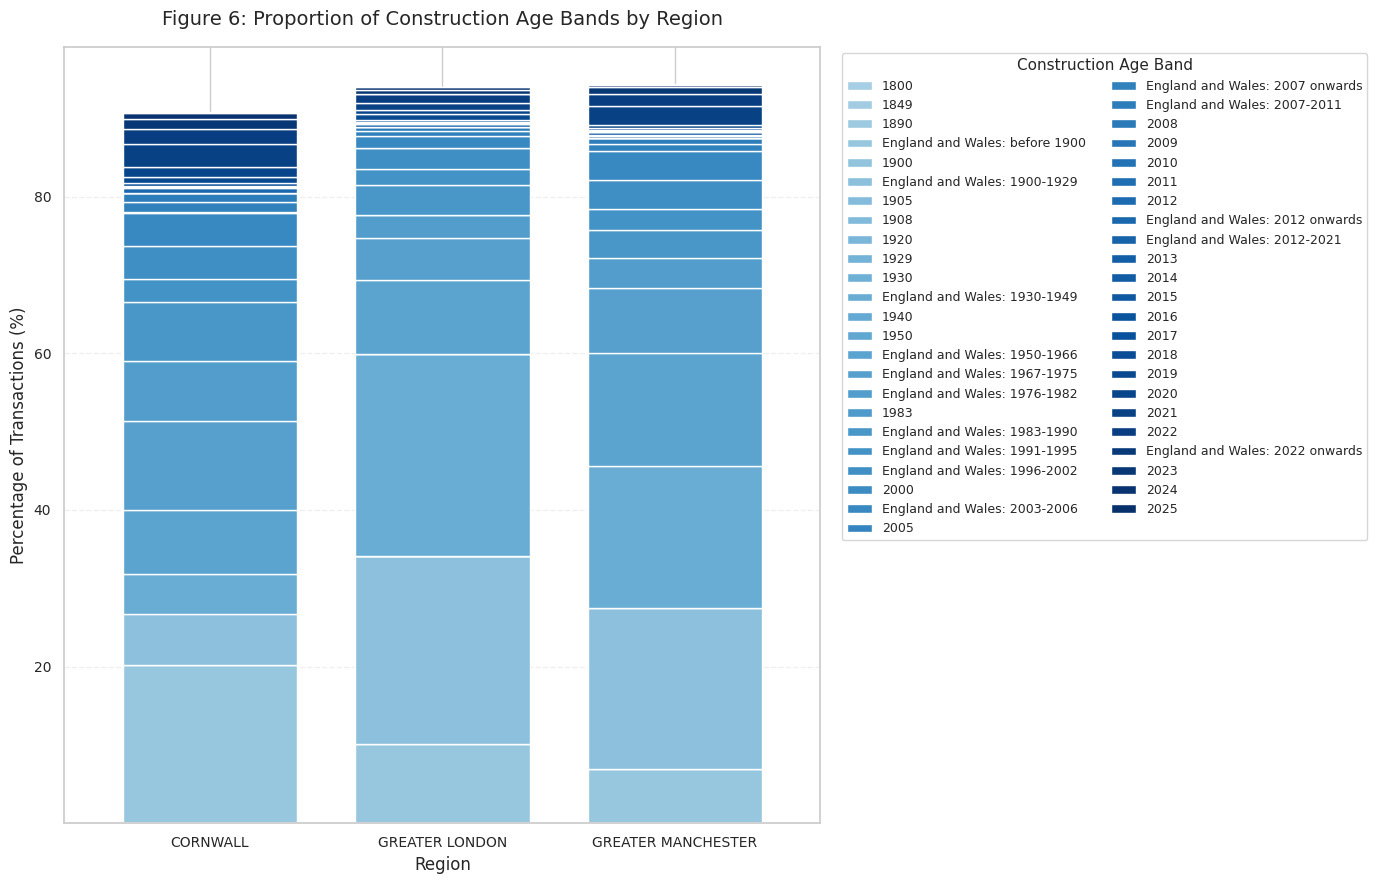

In [ ]:
# Figure 6 — Proportion of Construction Age Bands by Region

# ── Data preparation ──────────────────────────────────────────────────────────
cross_age_region = pd.crosstab(
    df['County'],
    df['CONSTRUCTION_AGE_BAND'],
    normalize='index'
) * 100

# Drop invalid / placeholder bands
bands_to_remove = ['2042', 'INVALID!', 'Unknown']
cross_age_region.drop(
    columns=[c for c in bands_to_remove if c in cross_age_region.columns],
    inplace=True
)

# Extract the opening year from each band label for chronological sorting
def get_start_year(band):
    band = str(band).strip()
    if any(x in band.upper() for x in ['INVALID', 'UNKNOWN']):
        return 9999
    if 'before 1900' in band.lower():
        return 1899
    years = re.findall(r'\d{4}', band)
    if years:
        return int(min(years))
    if re.match(r'^\d{4}$', band):
        return int(band)
    return 9999

sorted_bands = sorted(cross_age_region.columns.tolist(), key=get_start_year)
cross_age_region = cross_age_region[sorted_bands]

# ── Plot ──────────────────────────────────────────────────────────────────────
# 1. Generate the colour palette in Seaborn

blues_d = LinearSegmentedColormap.from_list(
    'blues_d', plt.cm.Blues(np.linspace(0.35, 1.0, 256))
)

cross_age_region.plot(
    kind='bar',
    stacked=True,
    colormap=blues_d,   # <-- Using colormap with the converted palette
    figsize=(14, 9),
    edgecolor='white',
    width=0.75
)

plt.title('Figure 6: Proportion of Construction Age Bands by Region', fontsize=14, pad=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Percentage of Transactions (%)', fontsize=12)

plt.legend(
    title='Construction Age Band',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    fontsize=9,
    title_fontsize=11,
    ncol=2
)

plt.xticks(
    ticks=range(len(cross_age_region.index)),
    labels=[x.replace(' (County)', '').strip() for x in cross_age_region.index],
    rotation=0
)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

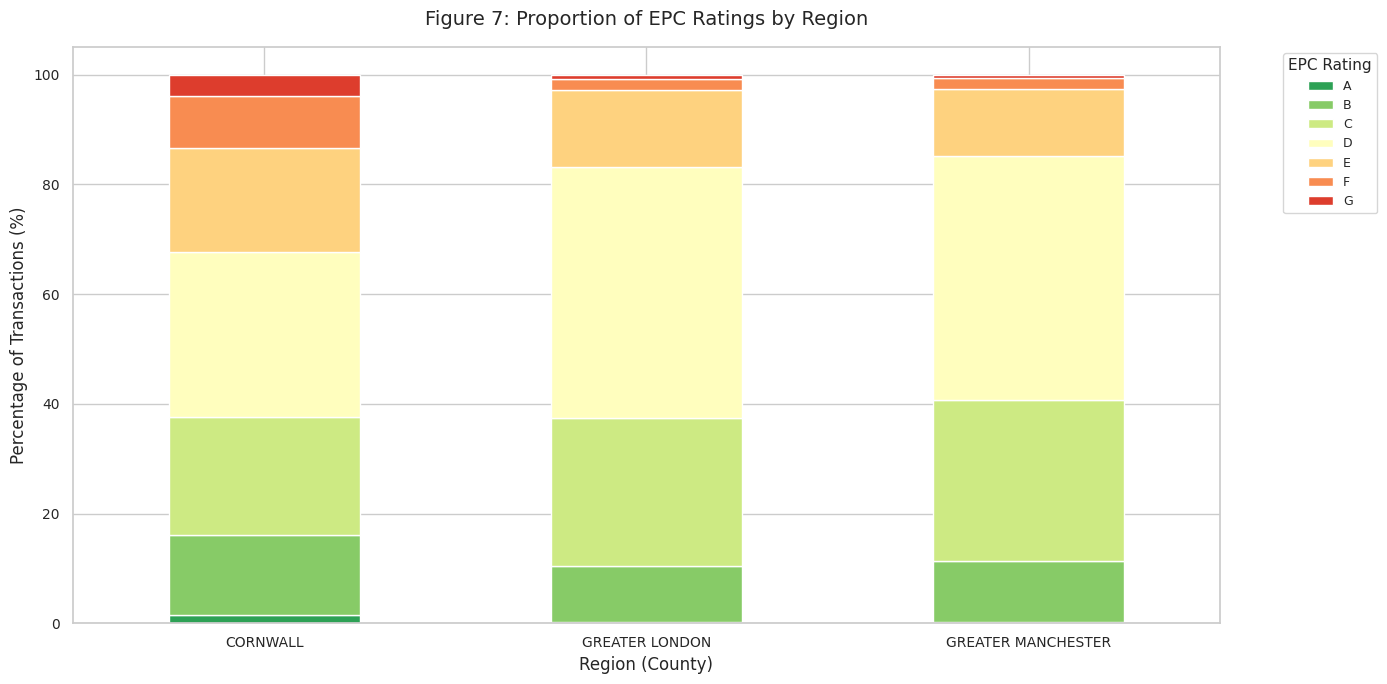

In [ ]:
# Figure 7 — Proportion of EPC Ratings by Region
# NOTE: RdYlGn_r is deliberately retained. This chart directly complements
# Figure 2 — the same green-to-red EPC colour coding must be visually
# consistent across the entire document for the narrative to hold.

epc_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

cross_region = (
    pd.crosstab(df['County'], df['CURRENT_ENERGY_RATING'], normalize='index') * 100
)
cross_region = cross_region.reindex(columns=epc_order)

cross_region.plot(
    kind='bar',
    stacked=True,
    color=PAL_EPC,
    figsize=(14, 7),
    edgecolor='white'
)

plt.title('Figure 7: Proportion of EPC Ratings by Region', fontsize=14, pad=16)
plt.xlabel('Region (County)', fontsize=12)
plt.ylabel('Percentage of Transactions (%)', fontsize=12)

plt.legend(
    title='EPC Rating',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

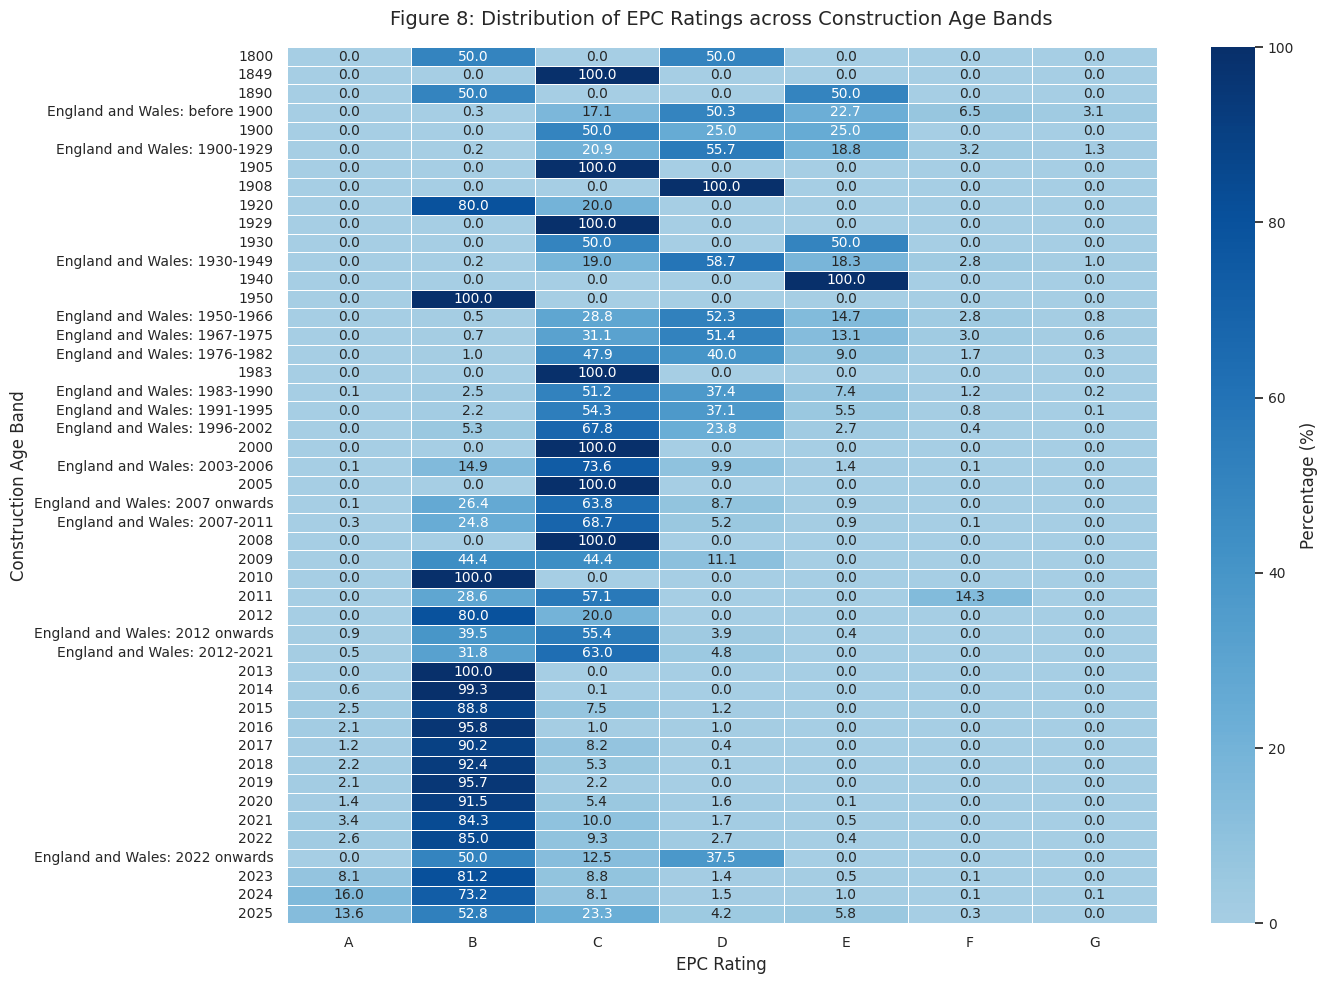

In [ ]:
# ─── CELL 9: Figure 8 — Distribution of EPC Ratings across Construction Age Bands

epc_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

cross_age = (
    pd.crosstab(df['CONSTRUCTION_AGE_BAND'], df['CURRENT_ENERGY_RATING'], normalize='index') * 100
)
cross_age = cross_age.reindex(columns=epc_order)

# Reuse bands_to_remove and get_start_year defined in Figure 6 cell
cross_age.drop(
    index=[b for b in bands_to_remove if b in cross_age.index],
    inplace=True
)

sorted_bands = sorted(cross_age.index.tolist(), key=get_start_year)
cross_age = cross_age.loc[sorted_bands]

plt.figure(figsize=(14, 10))
sns.heatmap(
    cross_age,
    annot=True,
    fmt='.1f',
    cmap=blues_d,
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Percentage (%)'},
    annot_kws={'size': 10}
)

plt.title('Figure 8: Distribution of EPC Ratings across Construction Age Bands', fontsize=14, pad=16)
plt.xlabel('EPC Rating', fontsize=12)
plt.ylabel('Construction Age Band', fontsize=12)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Step 4: Data Transformation and Train-Test Split

In this stage, categorical data is prepared for the mathematical modelling algorithms, and the dataset is partitioned to ensure a fair evaluation of the models (preventing data leakage).

1. **Ordinal Encoding:** The `CURRENT_ENERGY_RATING` variable is converted into an ordinal numerical scale (A=7 to G=1), reflecting the energy efficiency hierarchy.
2. **One-Hot Encoding:** Nominal variables (such as `Property_Type`, `Postcode_Outcode`, etc.) are transformed into binary variables (0 and 1). The `drop_first=True` parameter is strictly enforced to avoid the Dummy Variable Trap (perfect multicollinearity), which is a requisite condition for the baseline Ordinary Least Squares (OLS) model.
3. **Train-Test Split:** The dataset is partitioned into 80% for model training and 20% for testing (final validation). The `random_state=42` parameter is fixed in accordance with scientific reproducibility best practices (CRISP-ML methodology).

In [ ]:
# Data Transformation and Train-Test Split

print("--- Step 4: Data Transformation and Train-Test Split ---")

# 1. Ordinal Encoding: A = 7 (most efficient) → G = 1 (least efficient)
epc_mapping = {'A': 7, 'B': 6, 'C': 5, 'D': 4, 'E': 3, 'F': 2, 'G': 1}
df['CURRENT_ENERGY_RATING'] = df['CURRENT_ENERGY_RATING'].map(epc_mapping)
print("✅ Ordinal Encoding complete.")

# 2. One-Hot Encoding with drop_first=True (avoids Dummy Variable Trap for OLS baseline)
categorical_cols = [
    'Property_Type',
    'Old_New',
    'Tenure_Duration',
    'CONSTRUCTION_AGE_BAND',
    'Postcode_Outcode',
    'Year_of_Transfer',
    'Month_of_Transfer'
]
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Convert boolean dummies to integers for full ML compatibility
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f"✅ One-Hot Encoding complete. Columns: {df.shape[1]} → {df_encoded.shape[1]}.")

# 3. Train-Test Split (80/20, random_state=42 for reproducibility — CRISP-ML standard)
X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("✅ Train-Test Split complete.")
print(f"   Train set : {X_train.shape[0]:,} transactions")
print(f"   Test set  : {X_test.shape[0]:,} transactions")

display(X_train.head(3))